In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.src import data_loader

from algo_regime.src import regime_detector 
import gmmhmm




# (1) Data Pipeline Overview

## Index Universe

We track **9 major stock indices** across three regions:

| Region   | Index          | Ticker  |
|----------|----------------|---------|
| America  | S&P 500        | ^GSPC   |
| America  | Dow Jones      | ^DJI    |
| America  | Nasdaq         | ^IXIC   |
| Europe   | FTSE 100       | ^FTSE   |
| Europe   | CAC 40         | ^FCHI   |
| Europe   | DAX            | ^GDAXI  |
| Asia     | KOSPI          | ^KS11   |
| Asia     | Nikkei 225     | ^N225   |
| Asia     | Hang Seng      | ^HSI    |

## Raw Data Structure

Each index is downloaded from Yahoo Finance with **daily OHLCV** columns:
```
Date | Open | High | Low | Close | Volume
```

After merging, the full DataFrame uses a **MultiIndex on columns**: `(index_name, OHLCV_field)`, so accessing S&P 500 closing prices looks like `df["SP500"]["Close"]`.

## Feature Engineering

From the closing prices, two families of features are computed:

**1. Log-returns** over multiple horizons (default: 1, 5, 21 trading days):

$$r_{t,p} = \ln\left(\frac{P_t}{P_{t-p}}\right)$$

**2. Rolling annualised volatility** (default windows: 21 and 63 days):

$$\sigma_{t,w} = \text{std}\left(r_{t-w:t}\right) \times \sqrt{252}$$

This produces a feature matrix of shape `(T, 9 × (3 returns + 2 vols)) = (T, 45)` columns, where each row is one trading day and each column is `(index_name, feature_name)`.

## Pipeline Summary
```
Yahoo Finance API
       │
       ▼
  Raw OHLCV (per index)
       │
       ▼
  Merged DataFrame (MultiIndex columns)
       │
       ▼
  Close prices only (simple DataFrame)
       │
       ├──► Log-returns (1d, 5d, 21d)
       │
       ├──► Rolling volatility (21d, 63d)
       │
       ▼
  Feature matrix → Clustering / PCA
```

In [143]:
start_date = '2010-01-01'
end_date = '2024-01-01'
interval = '1d'



## (1.1) America Data 

- Dow Jones Index
- S&P 500 Index
- NASDAQ Index 

In [144]:
df_america = data_loader.get_close_prices(start_date=start_date, end_date=end_date, regions=['america'], interval=interval)
df_america.head()
print(df_america.shape)

(3522, 3)


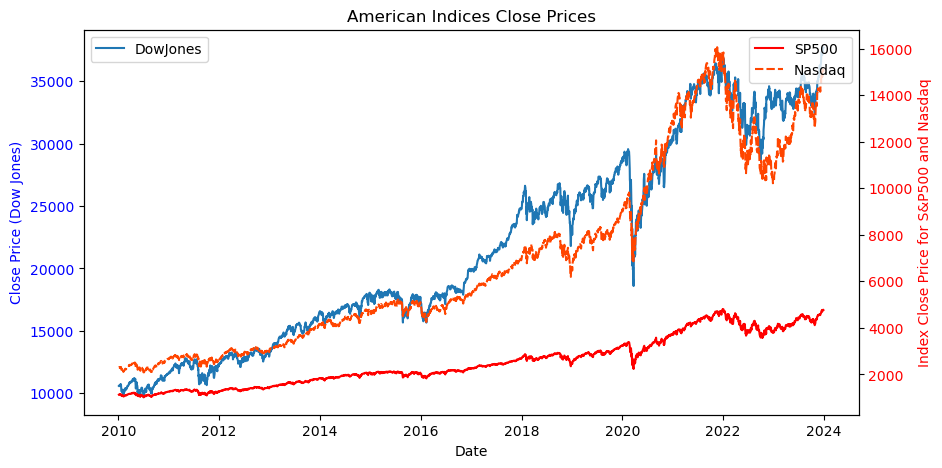

In [145]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_america.drop(columns=['SP500', 'Nasdaq']), ax=ax)
ax2 = ax.twinx()
sns.lineplot(data=df_america[['SP500', 'Nasdaq']], ax=ax2, palette=['red', 'orangered'])
ax2.set_ylabel('Index Close Price for S&P500 and Nasdaq', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax.set_title('American Indices Close Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (Dow Jones)', color= 'b')
ax.tick_params(axis='y', labelcolor='b')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# (1.2) Asia Data 

- Nikkei 225
- Kospi 
- Hang Seng 

In [146]:
df_asia = data_loader.get_close_prices(start_date=start_date, end_date=end_date, regions=['asia'], interval=interval)
df_asia.head()
print(df_asia.shape)

(3636, 3)


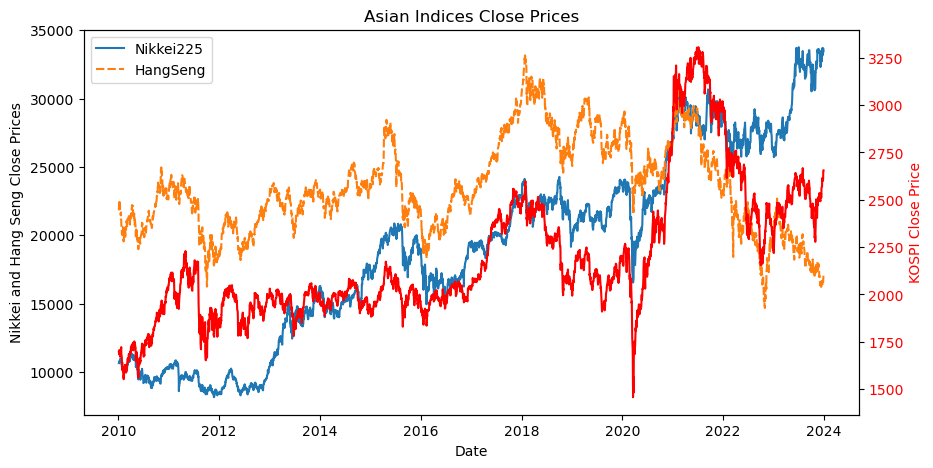

In [147]:
fig ,ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_asia.drop(columns=['KOSPI']), ax=ax)
ax.set_title('Asian Indices Close Prices')
#add a  different scale for the KOSPI index
ax2 = ax.twinx()
sns.lineplot(data=df_asia['KOSPI'], ax=ax2, color='r')
ax2.set_ylabel('KOSPI Close Price', color='r')
ax2.tick_params(axis='y', labelcolor='r')


ax.set_xlabel('Date')
ax.set_ylabel('Nikkei and Hang Seng Close Prices')
plt.show()

# (1.3) Europe Data 

- Cac 40
- DAX
- FTSE 100

In [148]:
df_europe = data_loader.get_close_prices(start_date=start_date, end_date=end_date, regions=['europe'], interval=interval)
df_europe.head()
print(df_europe.shape)

(3593, 3)


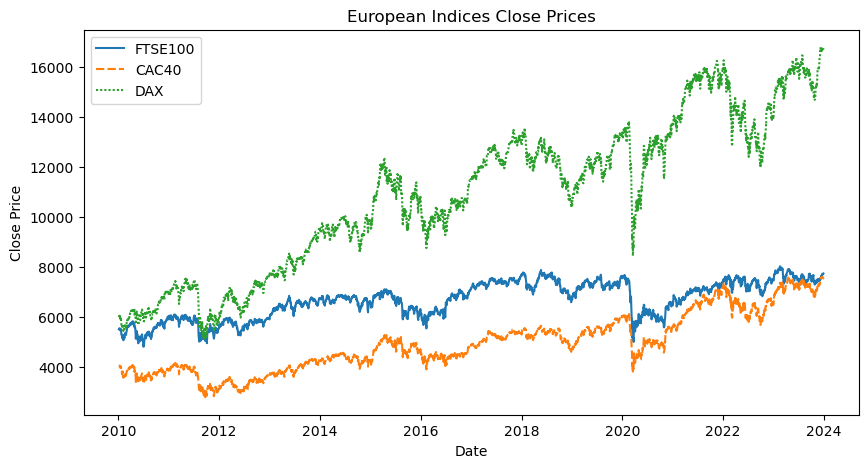

In [149]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_europe, ax=plt.gca())
plt.title('European Indices Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

# (2) K-means with PCA to detect regime  

## The Mathematics of K-Means Regime Detection

### Phase 1: Feature Engineering (State Encoding)

To transform sequential time-series data into cross-sectional features, we calculate several rolling metrics for each trading day $t$:

**1. Log Returns**
Ensures stationarity and additive symmetry over $p$ periods:
$$r_{t, p} = \ln\left(\frac{P_t}{P_{t-p}}\right)$$

**2. Annualized Rolling Volatility**
Measures dispersion over a rolling window $w$ (scaled to 252 trading days):
$$\sigma_{t, w} = \sqrt{252} \cdot \sqrt{\frac{1}{w-1} \sum_{i=0}^{w-1} \left(r_{t-i} - \mu_{w}\right)^2}$$

**3. Rolling Cross-Correlation (Pearson)**
Captures co-movement between indices $X$ and $Y$, which often spikes during regime shifts (e.g., market panics):
$$\rho_{X,Y, t} = \frac{\sum_{i=0}^{w-1} (r_{X, t-i} - \bar{r}_X)(r_{Y, t-i} - \bar{r}_Y)}{\sqrt{\sum_{i=0}^{w-1} (r_{X, t-i} - \bar{r}_X)^2 \sum_{i=0}^{w-1} (r_{Y, t-i} - \bar{r}_Y)^2}}$$

**4. Momentum Z-Score**
Measures mean-reversion by normalizing the distance between current price and a moving average:
$$Z_t = \frac{P_t - \mu_{\text{MA}}}{\sigma_{\text{lookback}}}$$

---

### Phase 2: Dimensionality Reduction

**1. Standardization**
Normalizes features so algorithms based on Euclidean distance do not overweight features with larger absolute bounds:
$$z_{t,j} = \frac{x_{t,j} - \mu_j}{\sigma_j}$$

**2. Principal Component Analysis (PCA)**
Addresses collinearity by projecting the matrix onto an orthogonal subspace. It solves for the eigenvectors $\mathbf{v}$ and eigenvalues $\lambda$ of the covariance matrix $\boldsymbol{\Sigma}$:
$$\boldsymbol{\Sigma} \mathbf{v} = \lambda \mathbf{v}$$

---

### Phase 3: K-Means Objective Function

K-Means seeks to partition the trading days into $K$ distinct regimes by minimizing the **Within-Cluster Sum of Squares (WCSS)**, or Inertia $J$. It minimizes the squared distance between each day's feature vector $\mathbf{x}_t$ and its assigned regime centroid $\boldsymbol{\mu}_k$:
$$J = \sum_{k=1}^{K} \sum_{\mathbf{x}_t \in S_k} \|\mathbf{x}_t - \boldsymbol{\mu}_k\|^2$$

---

### Phase 4: Optimal $K$-Selection

To rigorously determine the correct number of regimes, we calculate the **Silhouette Score** for each day $i$. This metric evaluates cohesion $a(i)$ (average distance to days in the same regime) versus separation $b(i)$ (average distance to days in the nearest different regime):
$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$
*A mean score closer to 1.0 indicates dense, well-separated regimes.*

## (2.1) Regime detection on American Indices 

In [292]:
from algo_regime.src import regime_detector
from algo_regime.src import metrics
import gmmhmm  
import importlib
importlib.reload(regime_detector)
importlib.reload(metrics)
rd_america = regime_detector.RegimeDetector(df_america, use_pca = True, n_regimes= None)
rd_america.fit_train_test(split_date='2020-01-01')
regime_labels_ptt = rd_america.peak_to_trough_labelling(drawdown_threshold=-0.1)
skmeans_labels = rd_america.detect_regime_skmeans(N_S = 10, L = 100, h1 = 60, h2 = 12, epsilon = 1e-6)

Fitting KMeans for k=2... with X shape (2453, 7)
Fitting KMeans for k=3... with X shape (2453, 7)
Fitting KMeans for k=4... with X shape (2453, 7)
Fitting KMeans for k=5... with X shape (2453, 7)
Fitting KMeans for k=6... with X shape (2453, 7)
Fitting KMeans for k=7... with X shape (2453, 7)
Fitting KMeans for k=8... with X shape (2453, 7)
3522
shape of close: (3522, 3)
Simulation 1/10 completed. Evaluating accuracy...
Simulation 2/10 completed. Evaluating accuracy...
Simulation 3/10 completed. Evaluating accuracy...
Simulation 4/10 completed. Evaluating accuracy...
Simulation 5/10 completed. Evaluating accuracy...
Simulation 6/10 completed. Evaluating accuracy...
Simulation 7/10 completed. Evaluating accuracy...
Simulation 8/10 completed. Evaluating accuracy...
Simulation 9/10 completed. Evaluating accuracy...
Simulation 10/10 completed. Evaluating accuracy...
(3522,)


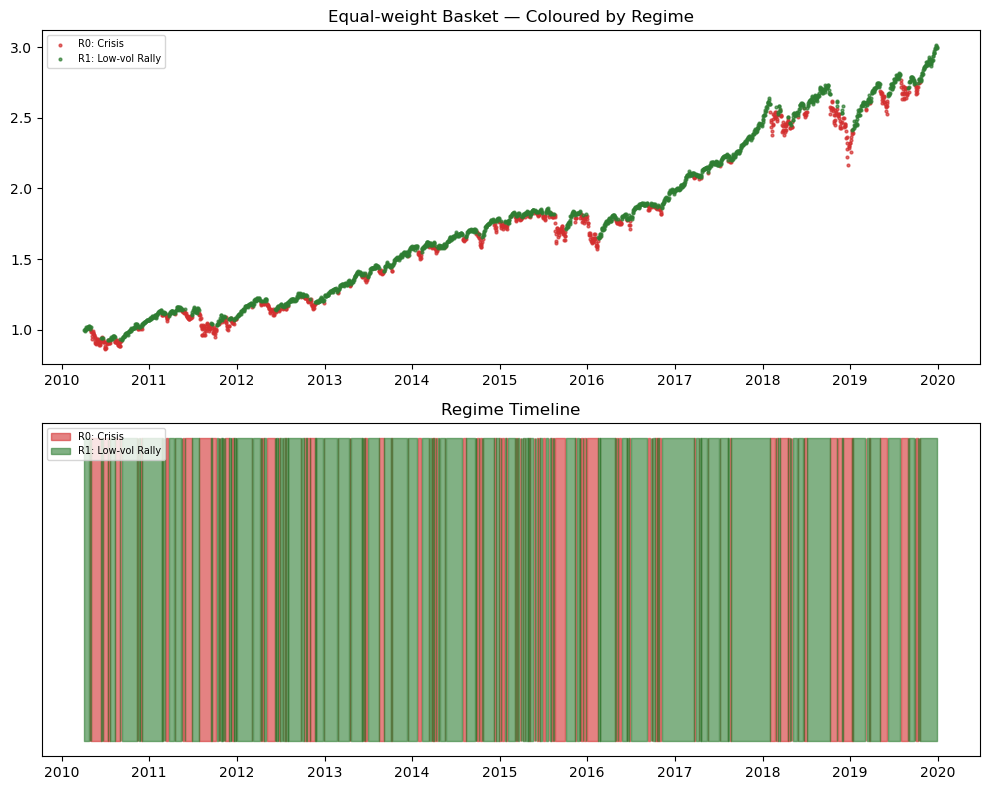

In [293]:
rd_america.fit_train_test(split_date='2020-01-01')
fig = rd_america.plot_regime_profile_train_only()
fig.savefig('graphs/regime_profile_america.png')


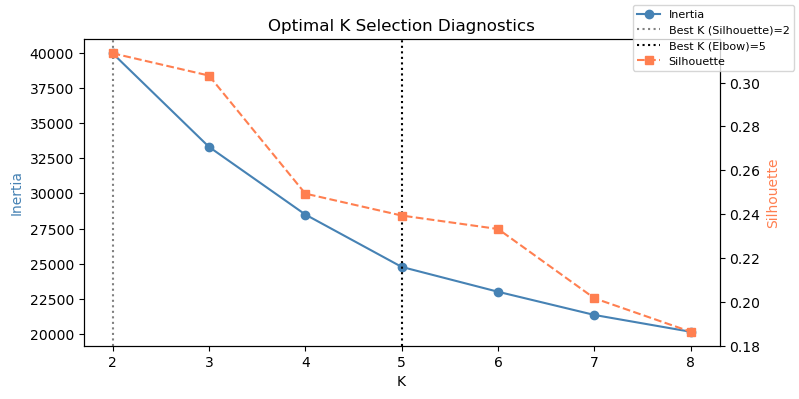

In [294]:
rd_america.fit_train_test(split_date='2020-01-01')
fig = rd_america.plot_k_selection()
fig.savefig('graphs/k_selection_america.png')


(3459, 24)
(3459, 24)
(3459, 8)
shape of feature_reduced: (3459, 8)


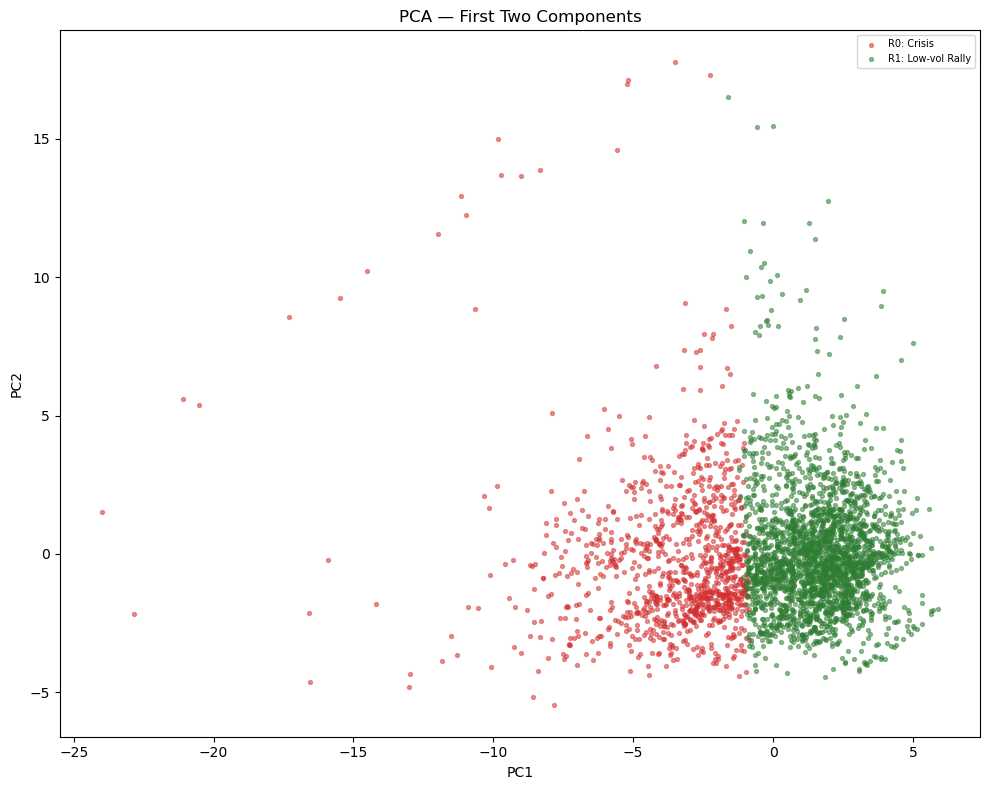

In [295]:
rd_america.fit()
fig = rd_america.plot_cluster_pca()
fig.savefig('graphs/cluster_pca_america.png')

### Train Model Comparison 


In [296]:
import gmmhmm
import importlib
importlib.reload(gmmhmm)

split_date = '2020-01-01'
rd_america.fit_train_test(split_date=split_date)

In [297]:
hmm_america = gmmhmm.HMMRegimeDetector(df_america, n_regimes=2, use_pca=True, pca_variance=0.90)
hmm_america.fit()

hmm_america.fit_train_test(split_date=split_date)
bt_hmm_america = hmm_america.backtest(initial_capital=100, split_date=split_date)
print(bt_hmm_america.columns)


Index(['basket_ret', 'weight', 'weight_lag1', 'strategy_ret', 'cum_basket',
       'cum_strategy', 'sharpe_basket', 'sharpe_strategy', 'calmar_basket',
       'calmar_strategy', 'ann_vol_basket', 'ann_vol_strategy',
       'ann_ret_basket', 'ann_ret_strategy'],
      dtype='str')


In [298]:
bt_america = rd_america.backtest(initial_capital=100, split_date=split_date)
bt_america_skmeans = rd_america.backtest_skmeans(initial_capital=100, split_date=split_date)

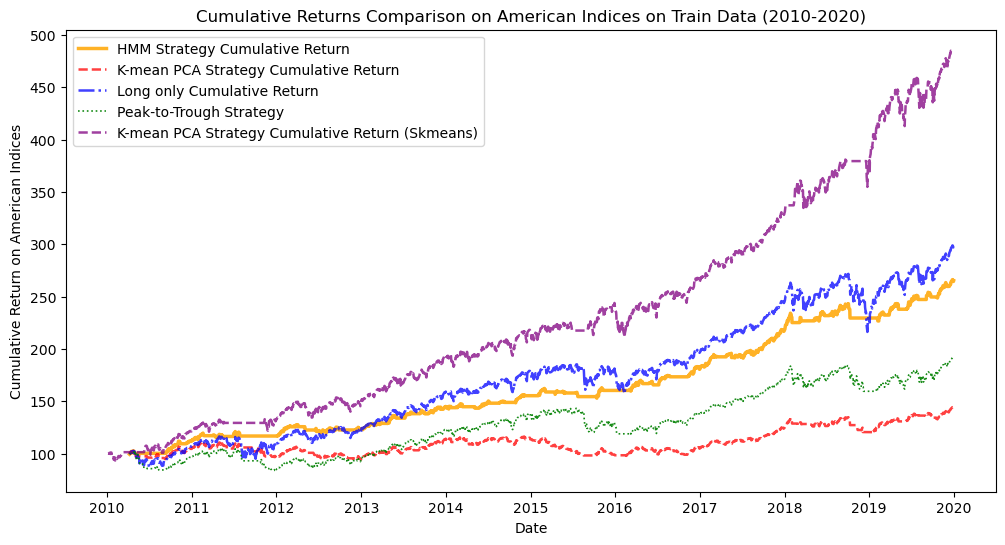

In [299]:


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(bt_hmm_america['cum_strategy'], label='HMM Strategy Cumulative Return',
        color='orange', linewidth=2.5, alpha=0.85)
ax.plot(bt_america['cum_strategy'], label='K-mean PCA Strategy Cumulative Return',
        color='red', linewidth=1.8, alpha=0.75, linestyle='--')
ax.plot(bt_america['cum_basket'], label='Long only Cumulative Return',
        color='blue', linewidth=1.8, alpha=0.75, linestyle='-.')
ax.plot(bt_america["cum_strategy_ptt"], label='Peak-to-Trough Strategy',
        color='green', linewidth=1.2, alpha=0.9, linestyle=':')

ax.plot(bt_america_skmeans['cum_strategy_skmeans'], label='K-mean PCA Strategy Cumulative Return (Skmeans)',
        color='purple', linewidth=1.8, alpha=0.75, linestyle='--')

ax.set_title('Cumulative Returns Comparison on American Indices on Train Data (2010-2020)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return on American Indices') 
ax.legend()

In [300]:
print("-- Backtest Summary Train --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_america['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_america['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Annualized Return : {bt_america["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_america["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_america['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_america['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Annualized Return (HMM): {bt_hmm_america["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_america["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_america_skmeans['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_america_skmeans['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Annualized Return (sWkmeans): {bt_america_skmeans["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_america_skmeans["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_america['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_america['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Annualized Return (PTT): {bt_america["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_america["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_america['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_america['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Annualized Return (Basket): {bt_america["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_america["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary Train --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 143.93
Sharpe Ratio : 0.46
Annualized Return : 0.04
Annualized Volatility : 0.09
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 265.31
Sharpe Ratio (HMM): 1.60
Annualized Return (HMM): 0.11
Annualized Volatility (HMM): 0.06
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 484.99
Sharpe Ratio (sWkmeans): 1.38
Annualized Return (sWkmeans): 0.17
Annualized Volatility (sWkmeans): 0.12
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 191.29
Sharpe Ratio (PTT): 0.59
Annualized Return (PTT): 0.07
Annualized Volatility (PTT): 0.13
---------------------- Long Only Performance ----------------------
Final Cumulative Return (Basket): 297.93
Sharpe Ratio (Basket): 0.82
Annualized Return (

### TEST BACKTEST DATA ONLY

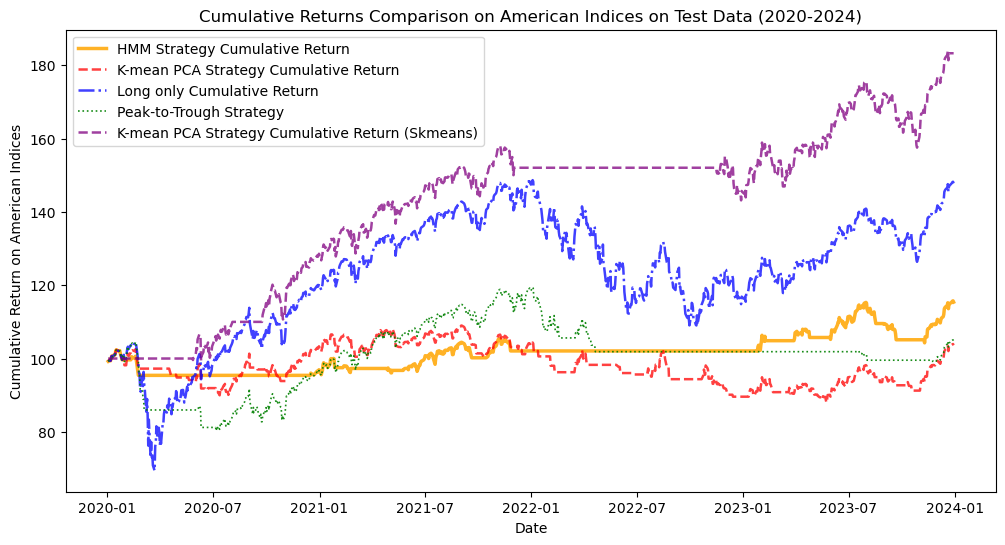

In [301]:
importlib.reload(regime_detector)

bt_america_test = rd_america.backtest_test_only(initial_capital=100)
bt_america_skmeans_test = rd_america.backtest_skmeans_test_only(initial_capital=100)
bt_hmm_america_test = hmm_america.backtest_test_only(initial_capital=100)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(bt_hmm_america_test['cum_strategy'], label='HMM Strategy Cumulative Return',
        color='orange', linewidth=2.5, alpha=0.85)
ax.plot(bt_america_test['cum_strategy'], label='K-mean PCA Strategy Cumulative Return',
        color='red', linewidth=1.8, alpha=0.75, linestyle='--')
ax.plot(bt_america_test['cum_basket'], label='Long only Cumulative Return',
        color='blue', linewidth=1.8, alpha=0.75, linestyle='-.')
ax.plot(bt_america_test["cum_strategy_ptt"], label='Peak-to-Trough Strategy',
        color='green', linewidth=1.2, alpha=0.9, linestyle=':')

ax.plot(bt_america_skmeans_test['cum_strategy_skmeans'], label='K-mean PCA Strategy Cumulative Return (Skmeans)',
        color='purple', linewidth=1.8, alpha=0.75, linestyle='--')

ax.set_title('Cumulative Returns Comparison on American Indices on Test Data (2020-2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return on American Indices')
ax.legend()
fig.savefig('graphs/cumulative_returns_comparison_america_test.png', dpi=300, bbox_inches='tight')

In [302]:
print("-- Backtest Summary TEST --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_america_test['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_america_test['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Annualized Return : {bt_america_test["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_america_test["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_america_test['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_america_test['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Annualized Return (HMM): {bt_hmm_america_test["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_america_test["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_america_skmeans_test['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_america_skmeans_test['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Annualized Return (sWkmeans): {bt_america_skmeans_test["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_america_skmeans_test["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_america_test['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_america_test['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Annualized Return (PTT): {bt_america_test["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_america_test["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_america_test['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_america_test['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Annualized Return (Basket): {bt_america_test["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_america_test["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary TEST --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 103.65
Sharpe Ratio : 0.14
Annualized Return : 0.01
Annualized Volatility : 0.11
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 115.39
Sharpe Ratio (HMM): 0.60
Annualized Return (HMM): 0.04
Annualized Volatility (HMM): 0.06
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 183.30
Sharpe Ratio (sWkmeans): 1.35
Annualized Return (sWkmeans): 0.16
Annualized Volatility (sWkmeans): 0.12
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 104.76
Sharpe Ratio (PTT): 0.16
Annualized Return (PTT): 0.01
Annualized Volatility (PTT): 0.12
---------------------- Long Only Performance ----------------------
Final Cumulative Return (Basket): 147.80
Sharpe Ratio (Basket): 0.54
Annualized Return (B

## (2.2) Regime Detection on European Indices 

In [303]:
from algo_regime.src import regime_detector 
import importlib
importlib.reload(regime_detector)
df_europe.dropna(inplace=True)
print(df_europe.head())
rd_europe= regime_detector.RegimeDetector(df_europe, use_pca = True, pca_variance=0.90)
rd_europe.fit()
regime_labels_ptt = rd_europe.peak_to_trough_labelling(drawdown_threshold=-0.1)
skmeans_labels = rd_europe.detect_regime_skmeans(N_S = 10, L = 100, h1 = 10, h2 = 7, epsilon = 1e-6)

                FTSE100        CAC40          DAX
Date                                             
2010-01-04  5500.299805  4013.969971  6048.299805
2010-01-05  5522.500000  4012.909912  6031.859863
2010-01-06  5530.000000  4017.669922  6034.330078
2010-01-07  5526.700195  4024.800049  6019.359863
2010-01-08  5534.200195  4045.139893  6037.609863
(3527, 24)
(3527, 24)
(3527, 7)
shape of feature_reduced: (3527, 7)
Fitting KMeans for k=2... with X shape (3527, 7)
Fitting KMeans for k=3... with X shape (3527, 7)
Fitting KMeans for k=4... with X shape (3527, 7)
Fitting KMeans for k=5... with X shape (3527, 7)
Fitting KMeans for k=6... with X shape (3527, 7)
Fitting KMeans for k=7... with X shape (3527, 7)
Fitting KMeans for k=8... with X shape (3527, 7)
3593
shape of close: (3593, 3)
Simulation 1/10 completed. Evaluating accuracy...
Simulation 2/10 completed. Evaluating accuracy...
Simulation 3/10 completed. Evaluating accuracy...
Simulation 4/10 completed. Evaluating accuracy...
Simulati

### Elbow Plot

(3527, 24)
(3527, 24)
(3527, 7)
shape of feature_reduced: (3527, 7)


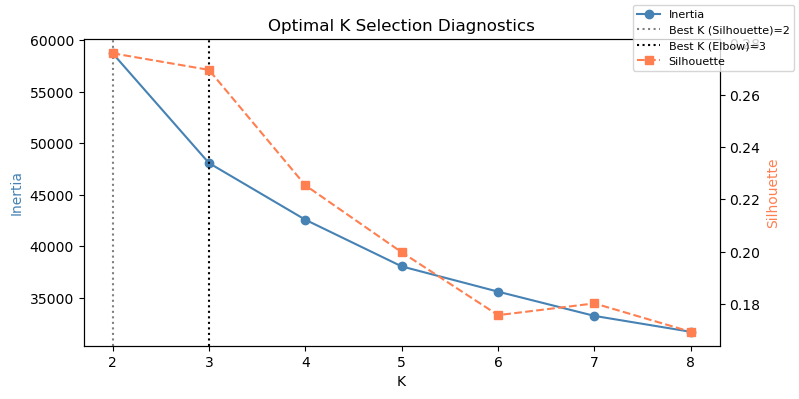

In [304]:
rd_europe.fit()
fig = rd_europe.plot_k_selection()
fig.savefig('graphs/k_selection_europe.png')

### Regime Prediction 

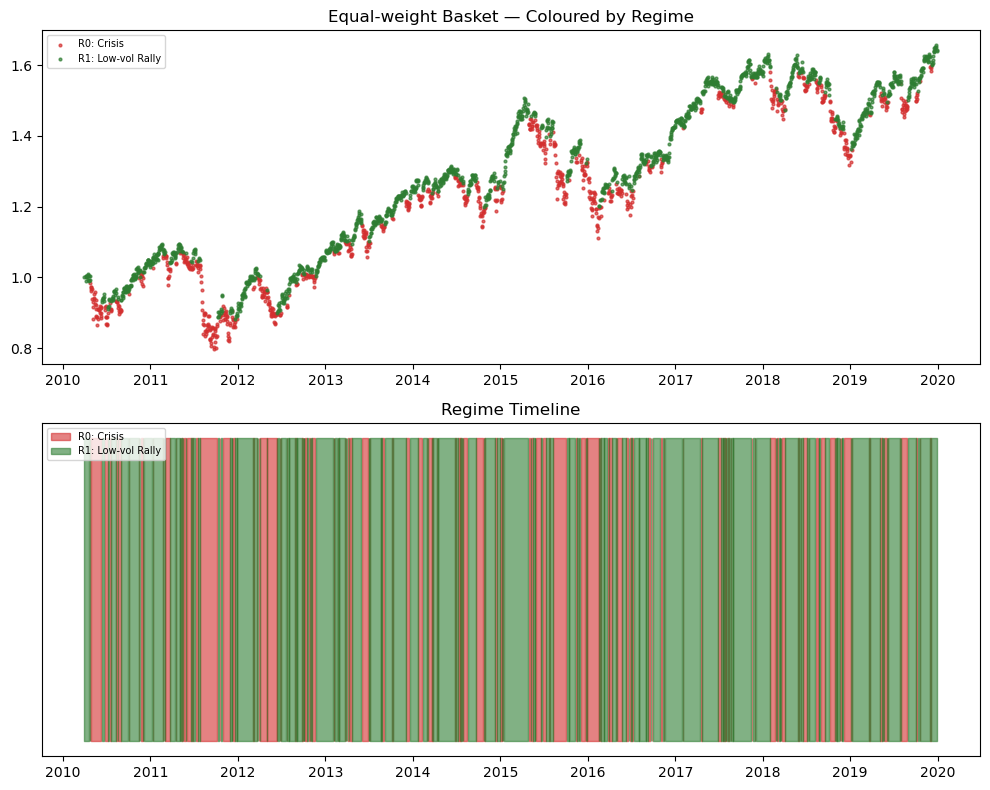

In [306]:
rd_europe.fit_train_test(split_date='2020-01-01')
fig = rd_europe.plot_regime_profile_train_only()
fig.savefig('graphs/regime_profile_europe.png')

(3527, 24)
(3527, 24)
(3527, 7)
shape of feature_reduced: (3527, 7)


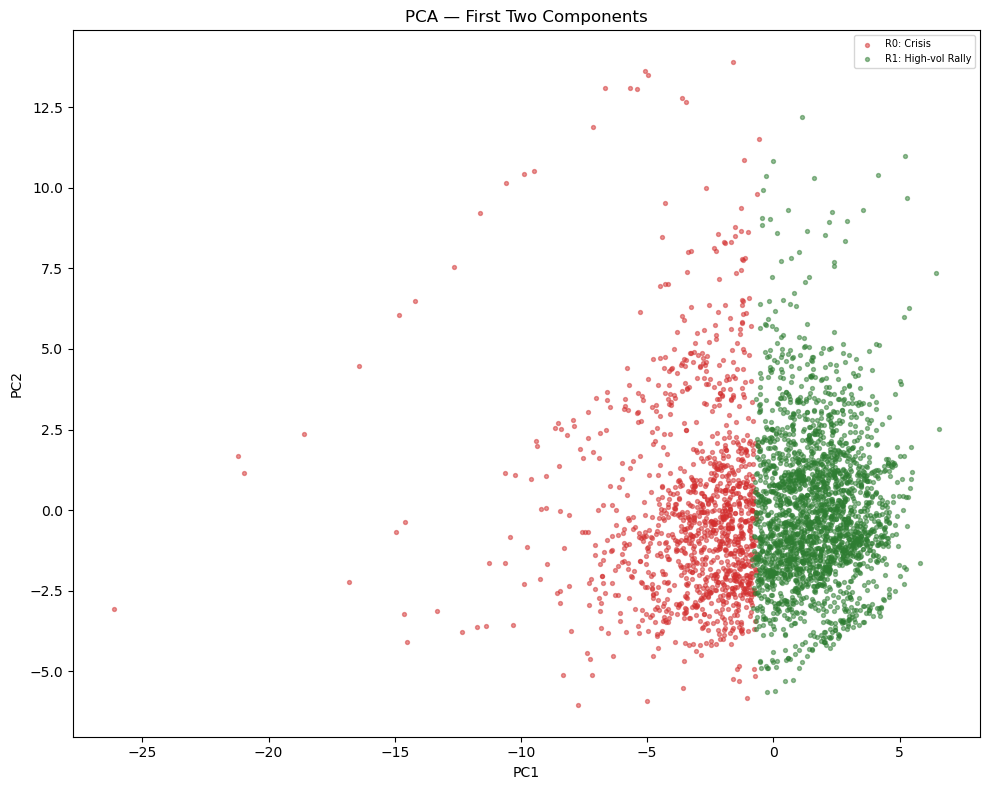

In [308]:
rd_europe.fit()
fig = rd_europe.plot_cluster_pca()
fig.savefig('graphs/cluster_pca_europe.png')

### Train data Backtest 

In [309]:
import gmmhmm
import importlib
importlib.reload(gmmhmm)

split_date = '2020-01-01'
rd_europe.fit_train_test(split_date=split_date)


In [266]:
hmm_europe = gmmhmm.HMMRegimeDetector(df_europe, n_regimes=2, use_pca=True)
hmm_europe.fit()

hmm_europe.fit_train_test(split_date=split_date)
bt_hmm_europe = hmm_europe.backtest(initial_capital=100, split_date=split_date)
print(bt_hmm_europe.columns)

Index(['basket_ret', 'weight', 'weight_lag1', 'strategy_ret', 'cum_basket',
       'cum_strategy', 'sharpe_basket', 'sharpe_strategy', 'calmar_basket',
       'calmar_strategy', 'ann_vol_basket', 'ann_vol_strategy',
       'ann_ret_basket', 'ann_ret_strategy'],
      dtype='str')


In [267]:
from algo_regime.src import regime_detector 
importlib.reload(regime_detector)

bt_europe = rd_europe.backtest(initial_capital=100, split_date=split_date)
bt_europe_skmeans = rd_europe.backtest_skmeans(initial_capital=100, split_date=split_date)

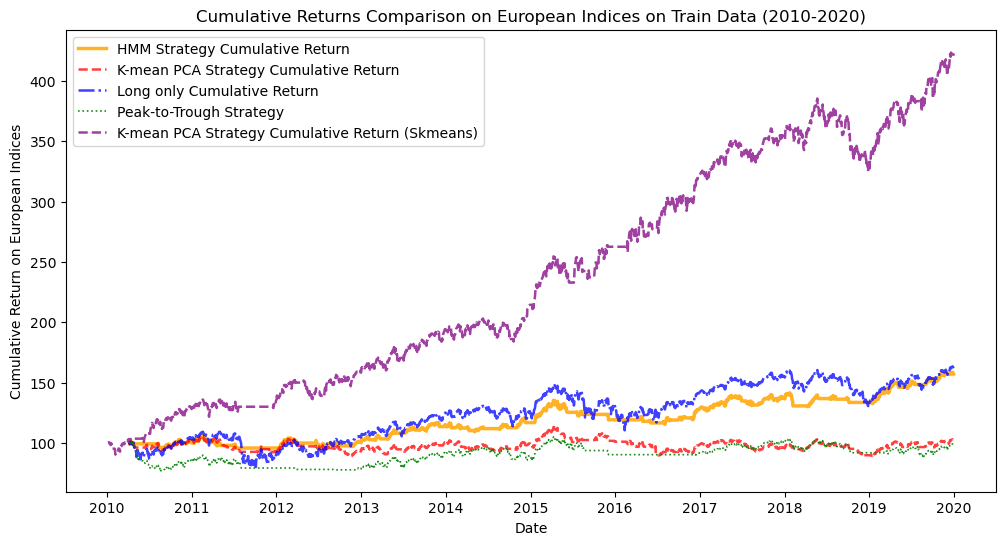

In [268]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(bt_hmm_europe['cum_strategy'], label='HMM Strategy Cumulative Return',
        color='orange', linewidth=2.5, alpha=0.85)
ax.plot(bt_europe['cum_strategy'], label='K-mean PCA Strategy Cumulative Return',
        color='red', linewidth=1.8, alpha=0.75, linestyle='--')
ax.plot(bt_europe['cum_basket'], label='Long only Cumulative Return',
        color='blue', linewidth=1.8, alpha=0.75, linestyle='-.')
ax.plot(bt_europe["cum_strategy_ptt"], label='Peak-to-Trough Strategy',
        color='green', linewidth=1.2, alpha=0.9, linestyle=':')
ax.plot(bt_europe_skmeans['cum_strategy_skmeans'], label='K-mean PCA Strategy Cumulative Return (Skmeans)',
        color='purple', linewidth=1.8, alpha=0.75, linestyle='--')


ax.set_title('Cumulative Returns Comparison on European Indices on Train Data (2010-2020)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return on European Indices')
fig.savefig('graphs/cumulative_returns_comparison_europe.png', dpi=300, bbox_inches='tight')
ax.legend()

In [269]:
print("-- Backtest Summary --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_europe['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_europe['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Annualized Return : {bt_europe["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_europe["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_europe['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_europe['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Annualized Return (HMM): {bt_hmm_europe["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_europe["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_europe_skmeans['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_europe_skmeans['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Annualized Return (sWkmeans): {bt_europe_skmeans["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_europe_skmeans["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_europe['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_europe['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Annualized Return (PTT): {bt_europe["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_europe["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_europe['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_europe['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Annualized Return (Basket): {bt_europe["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_europe["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 101.96
Sharpe Ratio : 0.07
Annualized Return : 0.00
Annualized Volatility : 0.10
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 157.05
Sharpe Ratio (HMM): 0.61
Annualized Return (HMM): 0.05
Annualized Volatility (HMM): 0.08
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 420.83
Sharpe Ratio (sWkmeans): 1.20
Annualized Return (sWkmeans): 0.15
Annualized Volatility (sWkmeans): 0.12
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 98.22
Sharpe Ratio (PTT): 0.04
Annualized Return (PTT): -0.00
Annualized Volatility (PTT): 0.11
---------------------- Long Only Performance ----------------------
Final Cumulative Return (Basket): 161.85
Sharpe Ratio (Basket): 0.37
Annualized Return (Basket

### Test Data Backtesting 

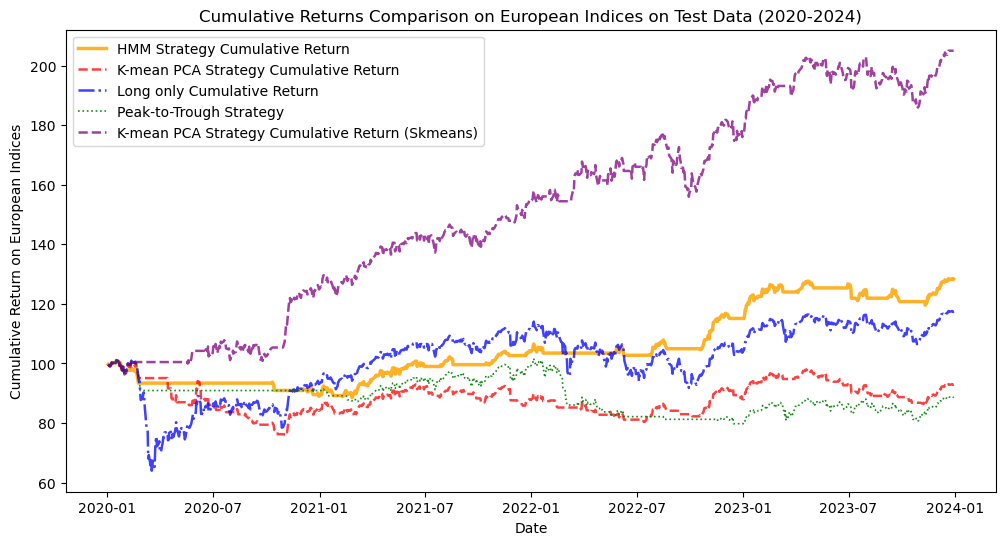

In [310]:
importlib.reload(regime_detector)
rd_europe.fit_train_test(split_date=split_date)
hmm_europe.fit_train_test(split_date=split_date)
bt_europe_test = rd_europe.backtest_test_only(initial_capital=100)
bt_europe_skmeans_test = rd_europe.backtest_skmeans_test_only(initial_capital=100)
bt_hmm_europe_test = hmm_europe.backtest_test_only(initial_capital=100)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(bt_hmm_europe_test['cum_strategy'], label='HMM Strategy Cumulative Return',
        color='orange', linewidth=2.5, alpha=0.85)
ax.plot(bt_europe_test['cum_strategy'], label='K-mean PCA Strategy Cumulative Return',
        color='red', linewidth=1.8, alpha=0.75, linestyle='--')
ax.plot(bt_europe_test['cum_basket'], label='Long only Cumulative Return',
        color='blue', linewidth=1.8, alpha=0.75, linestyle='-.')
ax.plot(bt_europe_test["cum_strategy_ptt"], label='Peak-to-Trough Strategy',
        color='green', linewidth=1.2, alpha=0.9, linestyle=':')

ax.plot(bt_europe_skmeans_test['cum_strategy_skmeans'], label='K-mean PCA Strategy Cumulative Return (Skmeans)',
        color='purple', linewidth=1.8, alpha=0.75, linestyle='--')

ax.set_title('Cumulative Returns Comparison on European Indices on Test Data (2020-2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return on European Indices')
ax.legend()
fig.savefig('graphs/cumulative_returns_comparison_europe_test.png', dpi=300, bbox_inches='tight')

In [311]:
print("-- Backtest Summary TEST --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_europe_test['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_europe_test['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Annualized Return : {bt_europe_test["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_europe_test["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_europe_test['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_europe_test['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Annualized Return (HMM): {bt_hmm_europe_test["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_europe_test["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_europe_skmeans_test['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_europe_skmeans_test['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Annualized Return (sWkmeans): {bt_europe_skmeans_test["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_europe_skmeans_test["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_europe_test['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_europe_test['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Annualized Return (PTT): {bt_europe_test["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_europe_test["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_europe_test['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_europe_test['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Annualized Return (Basket): {bt_europe_test["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_europe_test["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary TEST --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 92.96
Sharpe Ratio : -0.11
Annualized Return : -0.02
Annualized Volatility : 0.11
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 128.35
Sharpe Ratio (HMM): 0.87
Annualized Return (HMM): 0.06
Annualized Volatility (HMM): 0.07
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 204.98
Sharpe Ratio (sWkmeans): 1.44
Annualized Return (sWkmeans): 0.19
Annualized Volatility (sWkmeans): 0.13
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 88.86
Sharpe Ratio (PTT): -0.22
Annualized Return (PTT): -0.03
Annualized Volatility (PTT): 0.11
---------------------- Long Only Performance ----------------------
Final Cumulative Return (Basket): 117.51
Sharpe Ratio (Basket): 0.30
Annualized Return 

## (2.3) Regime detection on Asian Indices 

In [312]:
from algo_regime.src import regime_detector 
import importlib
importlib.reload(regime_detector)
df_asia.dropna(inplace=True)
print(df_asia.head())
rd_asia= regime_detector.RegimeDetector(df_asia, use_pca = True, pca_variance=0.90)
rd_asia.fit()
regime_labels_ptt = rd_asia.peak_to_trough_labelling(drawdown_threshold=-0.1)
skmeans_labels = rd_asia.detect_regime_skmeans(N_S = 10, L = 100, h1 = 60, h2 = 10, epsilon = 1e-6)

                  KOSPI     Nikkei225      HangSeng
Date                                               
2010-01-04  1696.140015  10654.790039  21823.279297
2010-01-05  1690.619995  10681.830078  22279.580078
2010-01-06  1705.319946  10731.450195  22416.669922
2010-01-07  1683.449951  10681.660156  22269.449219
2010-01-08  1695.260010  10798.320312  22296.750000
(3564, 24)
(3564, 24)
(3564, 11)
shape of feature_reduced: (3564, 11)
Fitting KMeans for k=2... with X shape (3564, 11)
Fitting KMeans for k=3... with X shape (3564, 11)
Fitting KMeans for k=4... with X shape (3564, 11)
Fitting KMeans for k=5... with X shape (3564, 11)
Fitting KMeans for k=6... with X shape (3564, 11)
Fitting KMeans for k=7... with X shape (3564, 11)
Fitting KMeans for k=8... with X shape (3564, 11)
3636
shape of close: (3636, 3)
Simulation 1/10 completed. Evaluating accuracy...
Simulation 2/10 completed. Evaluating accuracy...
Simulation 3/10 completed. Evaluating accuracy...
Simulation 4/10 completed. Evaluati

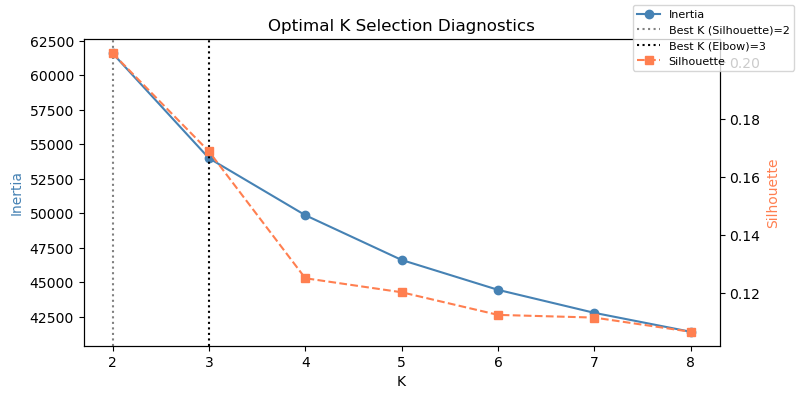

In [313]:
fig = rd_asia.plot_k_selection()
fig.savefig('graphs/k_selection_asia.png')

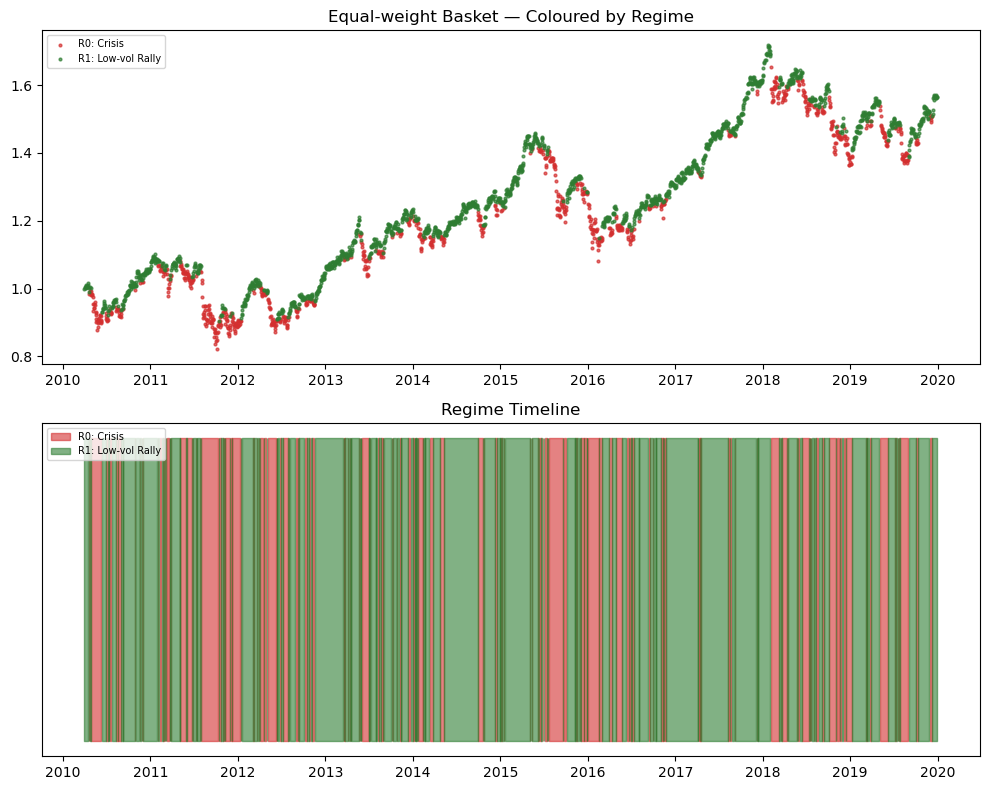

In [317]:
rd_asia.fit_train_test(split_date='2020-01-01')
fig = rd_asia.plot_regime_profile_train_only()
fig.savefig('graphs/regime_profile_asia.png')

(3564, 24)
(3564, 24)
(3564, 11)
shape of feature_reduced: (3564, 11)


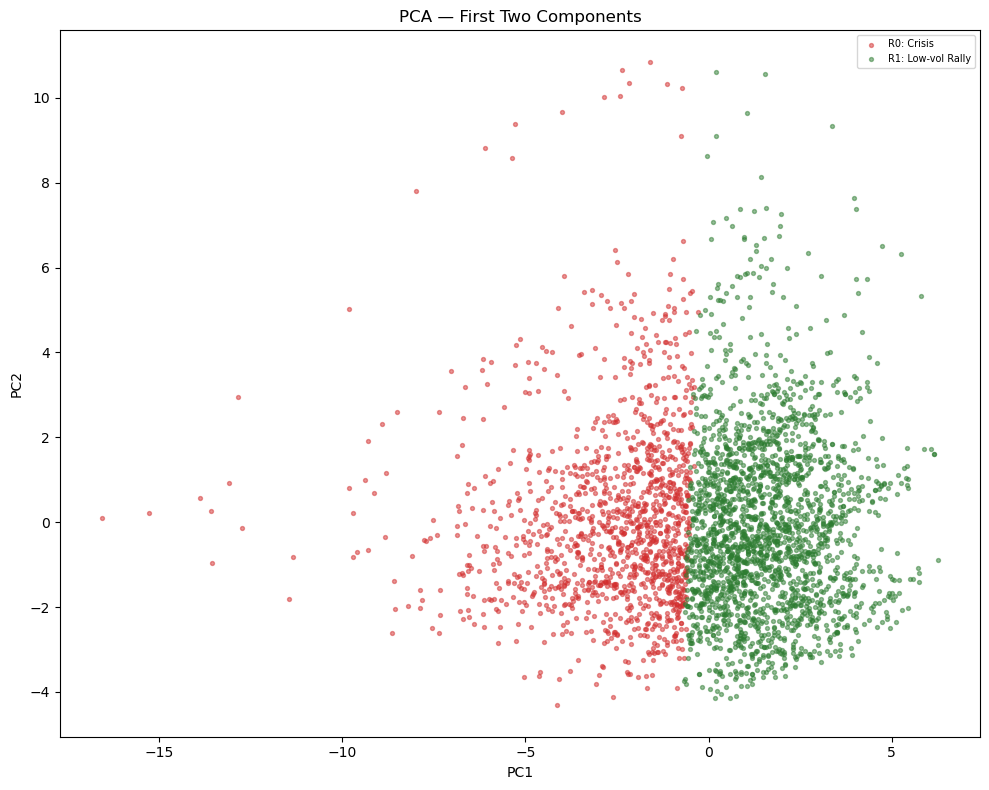

In [319]:
rd_asia.fit()
fig = rd_asia.plot_cluster_pca()
fig.savefig('graphs/cluster_pca_asia.png')

## Plot  Train Data Backtest

In [320]:
rd_asia.fit_train_test(split_date=split_date)
bt_asia = rd_asia.backtest(initial_capital=100, split_date=split_date)
bt_asia_skmeans = rd_asia.backtest_skmeans(initial_capital=100, split_date=split_date)
hmm_asia = gmmhmm.HMMRegimeDetector(df_asia, n_regimes=2, use_pca=True)
hmm_asia.fit_train_test(split_date=split_date)
bt_hmm_asia = hmm_asia.backtest(initial_capital=100, split_date=split_date)


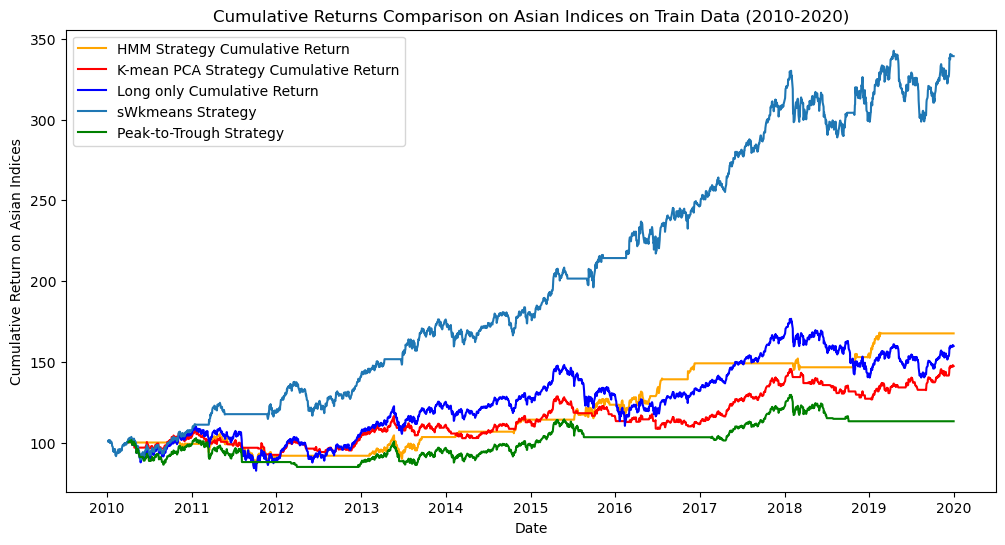

In [321]:
fig= plt.figure(figsize=(12, 6))
plt.plot(bt_hmm_asia['cum_strategy'], label='HMM Strategy Cumulative Return', color='orange')
plt.plot(bt_asia['cum_strategy'], label='K-mean PCA Strategy Cumulative Return', color='red')
plt.plot(bt_asia['cum_basket'], label='Long only Cumulative Return', color='blue')
plt.plot(bt_asia_skmeans['cum_strategy_skmeans'], label='sWkmeans Strategy')
plt.plot(bt_asia["cum_strategy_ptt"], label='Peak-to-Trough Strategy',color='green')
plt.title('Cumulative Returns Comparison on Asian Indices on Train Data (2010-2020)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return on Asian Indices')
plt.legend()
fig.savefig('graphs/cumulative_returns_comparison_asia.png')

In [322]:
print("-- Backtest Summary Train --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_asia['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_asia['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Annualized Return : {bt_asia["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_asia["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_asia['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_asia['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Annualized Return (HMM): {bt_hmm_asia["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_asia["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_asia_skmeans['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_asia_skmeans['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Annualized Return (sWkmeans): {bt_asia_skmeans["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_asia_skmeans["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_asia['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_asia['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Annualized Return (PTT): {bt_asia["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_asia["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_asia['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_asia['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Annualized Return (Basket): {bt_asia["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_asia["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary Train --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 147.32
Sharpe Ratio : 0.47
Annualized Return : 0.04
Annualized Volatility : 0.09
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 167.59
Sharpe Ratio (HMM): 0.59
Annualized Return (HMM): 0.05
Annualized Volatility (HMM): 0.10
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 339.30
Sharpe Ratio (sWkmeans): 1.05
Annualized Return (sWkmeans): 0.13
Annualized Volatility (sWkmeans): 0.12
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 113.16
Sharpe Ratio (PTT): 0.18
Annualized Return (PTT): 0.01
Annualized Volatility (PTT): 0.09
---------------------- Long Only Performance ----------------------
Final Cumulative Return (Basket): 159.74
Sharpe Ratio (Basket): 0.40
Annualized Return (

### Test Data 

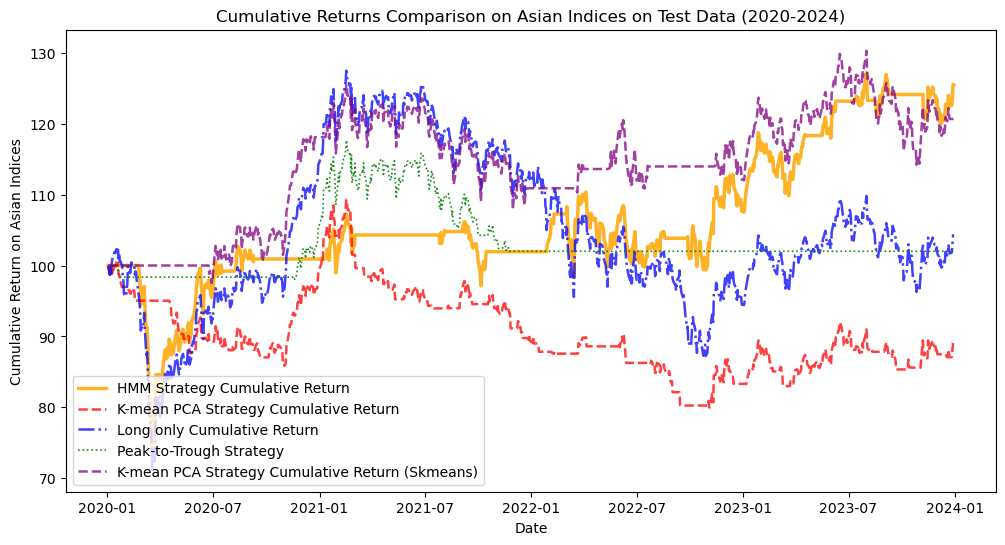

In [323]:
importlib.reload(regime_detector)
rd_asia.fit_train_test(split_date=split_date)
hmm_europe.fit_train_test(split_date=split_date)
bt_asia_test = rd_asia.backtest_test_only(initial_capital=100)
bt_asia_skmeans_test = rd_asia.backtest_skmeans_test_only(initial_capital=100)
bt_hmm_asia_test = hmm_asia.backtest_test_only(initial_capital=100)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(bt_hmm_asia_test['cum_strategy'], label='HMM Strategy Cumulative Return',
        color='orange', linewidth=2.5, alpha=0.85)
ax.plot(bt_asia_test['cum_strategy'], label='K-mean PCA Strategy Cumulative Return',
        color='red', linewidth=1.8, alpha=0.75, linestyle='--')
ax.plot(bt_asia_test['cum_basket'], label='Long only Cumulative Return',
        color='blue', linewidth=1.8, alpha=0.75, linestyle='-.')
ax.plot(bt_asia_test["cum_strategy_ptt"], label='Peak-to-Trough Strategy',
        color='green', linewidth=1.2, alpha=0.9, linestyle=':')

ax.plot(bt_asia_skmeans_test['cum_strategy_skmeans'], label='K-mean PCA Strategy Cumulative Return (Skmeans)',
        color='purple', linewidth=1.8, alpha=0.75, linestyle='--')

ax.set_title('Cumulative Returns Comparison on Asian Indices on Test Data (2020-2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return on Asian Indices')
ax.legend()
fig.savefig('graphs/cumulative_returns_comparison_asia_test.png', dpi=300, bbox_inches='tight')

In [324]:
print("-- Backtest Summary TEST --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_asia_test['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_asia_test['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Annualized Return : {bt_asia_test["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_asia_test["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_asia_test['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_asia_test['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Annualized Return (HMM): {bt_hmm_asia_test["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_asia_test["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_asia_skmeans_test['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_asia_skmeans_test['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Annualized Return (sWkmeans): {bt_asia_skmeans_test["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_asia_skmeans_test["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_asia_test['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_asia_test['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Annualized Return (PTT): {bt_asia_test["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_asia_test["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_asia_test['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_asia_test['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Annualized Return (Basket): {bt_asia_test["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_asia_test["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary TEST --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 89.13
Sharpe Ratio : -0.22
Annualized Return : -0.03
Annualized Volatility : 0.10
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 125.46
Sharpe Ratio (HMM): 0.44
Annualized Return (HMM): 0.06
Annualized Volatility (HMM): 0.15
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 120.66
Sharpe Ratio (sWkmeans): 0.44
Annualized Return (sWkmeans): 0.05
Annualized Volatility (sWkmeans): 0.12
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 102.01
Sharpe Ratio (PTT): 0.11
Annualized Return (PTT): 0.00
Annualized Volatility (PTT): 0.07
---------------------- Long Only Performance ----------------------
Final Cumulative Return (Basket): 104.19
Sharpe Ratio (Basket): 0.14
Annualized Return (

# (3) Hyperparameter tuning for the K-Mean Regime Detection Algorithm 